# Image Classification

This task involves an **image multi-class classification** problem. The goal is to construct a model capable of distinguishing between different types of playing cards. To minimize computational time, the number of classes has been reduced to the following set:

*   Ace of Hearts
*   Ace of Diamonds
*   Ace of Spades
*   Ace of Clubs







## Data Loading

## Data Visualization

In [1]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
import numpy as np

In [2]:
def plot_sample_images(base_path, images_per_class=2):
    # Get the list of subfolders (class names)
    classes = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    classes.sort() # Ensure alphabetical order

    num_classes = len(classes)

    # Create a grid: Rows = Classes, Cols = images_per_class
    fig, axes = plt.subplots(num_classes, images_per_class, figsize=(images_per_class * 3, num_classes * 3))

    # If there is only one class, wrap axes in a list to keep the loop working
    if num_classes == 1:
        axes = [axes]

    for i, class_name in enumerate(classes):
        class_path = os.path.join(base_path, class_name)
        # Get all image files in this subfolder
        all_images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Pick random samples
        sample_images = random.sample(all_images, min(images_per_class, len(all_images)))

        for j, img_name in enumerate(sample_images):
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)

            # Select the correct subplot
            ax = axes[i][j] if num_classes > 1 else axes[j]
            ax.imshow(img)
            ax.set_title(f"{class_name}\n{img_name}", fontsize=8)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

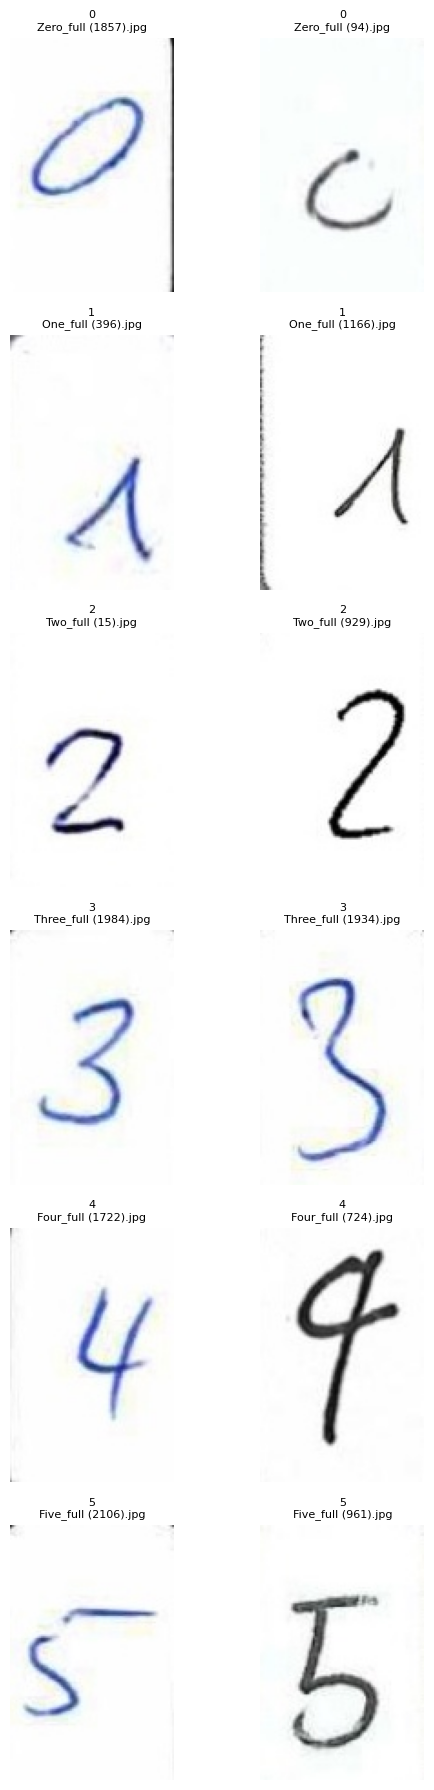

In [3]:
train_path = 'digits/train'

plot_sample_images(train_path, images_per_class=2)

## Data Analysis
Before proceeding to define a model for training, it is recommended to check whether the dataset is balanced. This helps determine the appropriate loss function and performance metrics.

We can plot a histogram to quickly assess the class distribution and ensure the data is balanced.




C:\Users\marco\AppData\Local\Temp\ipykernel_13852\2592260761.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_counts.index, y=df_counts.values, palette='viridis')


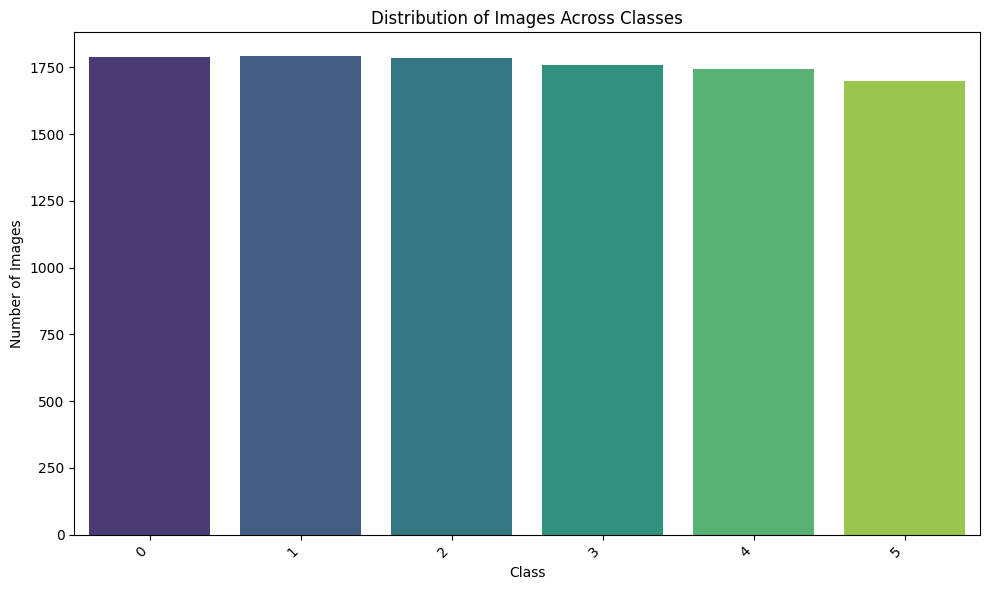

In [4]:
# Plot a histogram to assess data distribution across classes

train_dir = 'digits/train'

# Get a list of all class directories
class_names = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

# Count the number of images in each class
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    num_images = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
    class_counts[class_name] = num_images

# Convert to a pandas Series for easier plotting
import pandas as pd
df_counts = pd.Series(class_counts)

# Plotting the histogram (bar chart)
plt.figure(figsize=(10, 6))
sns.barplot(x=df_counts.index, y=df_counts.values, palette='viridis')
plt.title('Distribution of Images Across Classes')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Data Preprocessing

Since neural networks see images as grids of numerical values representing pixel intensity, images must be standardized before being fed into the network. Standardization typically includes three basic operations:

**Resizing:** Since the network expects an input of a fixed shape, providing images of different resolutions will cause the execution to fail. Therefore, we must ensure all images are adjusted to the same fixed resolution.

**Normalization:** It is often beneficial to normalize pixel values, scaling them to have a consistent mean and standard deviation. This helps the model reach faster convergence during training.

**Augmentation:** Data augmentation involves applying random transformations—such as rotations and translations—to prevent overfitting during the training phase. Important: This must be applied only to training data, NOT to test data, as doing so would modify and corrupt the evaluation task.





In [5]:
import torchvision.transforms as T

# Define the pipeline
training_transforms = T.Compose([
    T.Resize((224, 224)),                     # Standardize size. Keeping resolution low speeds up training
    T.ToTensor(),                             # Convert to Tensor
    T.Normalize(mean=[0.485, 0.456, 0.406],   # Center the data
                std=[0.229, 0.224, 0.225])
])

test_transforms = T.Compose([
    T.Resize((224, 224)),                     # Standardize size. Keeping resolution low speeds up training
    T.ToTensor(),                             # Convert to Matrix (0.0 - 1.0)
    T.Normalize(mean=[0.485, 0.456, 0.406],   # Center the data
                std=[0.229, 0.224, 0.225])
])

To bridge the gap between our files and our code, we use **ImageFolder**.
This class performs two operations:


1.   It turns folder names into numerical **labels**
2.   It applies our **transformations**

It returns a **list of tuples** in the form (item, label).
In our case, the item will be the image (represented as a tensor) and the label will be an integer.

For any ImageFolder instance I, we can access the first (image, label) tuple with I[0], and we can access the image and the label respectively with I[0][0] and I[0][1]



In [6]:
import torch
import torchvision.datasets as datasets # Import datasets module

test_dir = 'digits/test'

# Define the sets with different transforms
train_dataset = datasets.ImageFolder(root=train_dir, transform=training_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transforms)

print(f"Number of images in training set (all classes): {len(train_dataset)}")
print(f"Number of images in testing set (all classes): {len(test_dataset)}")

Number of images in training set (all classes): 10570
Number of images in testing set (all classes): 2647


In [7]:
# Print the shape of train dataset
print(train_dataset[0][0].shape)

# Print the shape of test dataset
print(test_dataset[0][0].shape)

torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


The **DataLoader** is a class that serves several key functions:


1.   **Batching**: To manage the limited memory of GPUs, it is more efficient to process data in mini-batches rather than all at once.
2.   **Shuffling**: To ensure effective learning, it is recommended to shuffle the data during training. This prevents the network from learning patterns related to the order of the data rather than the features of the data itself.
3.   **Parallel Loading**: To efficiently handle data preparation and preprocessing, the DataLoader creates sub-processes (workers) that allow the CPU and GPU to work independently. This prevents the GPU from sitting idle while the CPU prepares the next batch.

When iterating through a DataLoader, it returns two Tensors:


1.   A **4D Tensor of Images** with [32, 3, 224, 224] shape, where 32 are the images stacked together in the batch, 3 are the color channels (RGB), and 224x224 is the image resolution.

2.   A **1D Tensor of Labels** with [32] shape, containing the label for each image in the current batch.





In [8]:
from torch.utils.data import DataLoader

# Create the Training Loader
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,   # Always shuffle training data to ensure the model does not learn unwanted patterns,
                    # such as the first images are all aces of hearts (i.e., we want to avoid bias)
    num_workers=2   # Use 2 sub-processes to load data faster
)

# Create the Testing Loader
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,  # No need to shuffle test data; it doesn't affect the score
    num_workers=2
)

## Model Definition

In [9]:
# Fix the number of classes dynamically based on the dataset
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")

Number of classes: 6


### Multi-Layer Perceptron

In [10]:
import torch.nn as nn
import torch.nn.functional as F

class CardMLP(nn.Module):
    def __init__(self, num_classes=num_classes):
        super(CardMLP, self).__init__()
        # Input images are 3x224x224 (channels x height x width)
        # So, the flattened size is 3 * 224 * 224
        # self.input_size = 3 * 224 * 224
        self.input_size = 3 * 224 * 224


        self.fc1 = nn.Linear(self.input_size, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Flatten the image tensor
        x = x.view(-1, self.input_size)

        # Apply ReLU activation to hidden layers
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        # Output layer (no activation here, CrossEntropyLoss expects raw scores/logits)
        x = self.fc3(x)
        return x

print(f"MLP defined with {num_classes} output classes.")

MLP defined with 6 output classes.


### Convolutional Neural Network (CNN)

Convolutional Neural Networks (CNNs) are the primary type of neural network used for computer vision tasks. They are typically composed of three types of layers:


1.   **Convolutional Layers**: These layers function as learnable filters. A convolution operation is performed between the input image and these filters to extract the features (or "spatial signatures") of the image. They are responsible for identifying everything from simple edges to complex objects.
2.   **Maxpooling Layers**: These layers are used to reduce the spatial dimensions (height and width) of the feature maps. This downsampling helps make the features "translation invariant" (meaning the network can recognize a pattern even if it shifts slightly) and significantly speeds up computation by reducing the number of parameters.
3.  **Fully Connected Layers**: Also known as Dense Layers, these are located at the end of the network. They take the high-level features extracted by the previous layers and use them to make the final classification or prediction.



In [11]:
class CardCNN(nn.Module):
    def __init__(self, num_classes=num_classes):
        super(CardCNN, self).__init__()

        # First convolutional block
        # Input: 3x224x224 (RGB image)
        # Output: 16 feature maps
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces dimensions by half

        # Second convolutional block
        # Input: 16x112x112 (after pooling from conv1)
        # Output: 32 feature maps
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        # Third convolutional block
        # Input: 32x56x56 (after pooling from conv2)
        # Output: 64 feature maps
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # Fully connected layers
        # After 3 pooling layers (each reducing by a factor of 2),
        # 224 / 2 / 2 / 2 = 28. So the last feature map size is 64x28x28
        # Flattened size: 64 * 28 * 28 = 50176
        self.fc1 = nn.Linear(64 * 28 * 28, 512)

        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Apply first conv -> ReLU -> pool
        x = self.pool(F.relu(self.conv1(x)))
        # Apply second conv -> ReLU -> pool
        x = self.pool(F.relu(self.conv2(x)))
        # Apply third conv -> ReLU -> pool
        x = self.pool(F.relu(self.conv3(x)))

        # Flatten the feature maps for the fully connected layer
        # Ensure the view operation matches the fc1 input size
        x = x.view(-1, 64 * 28 * 28)

        # Apply fully connected layers with ReLU activation
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

print(f"CNN defined with {num_classes} output classes.")

CNN defined with 6 output classes.


 ### Training Loop

In [12]:
from sklearn.metrics import confusion_matrix

In [13]:
# Define models
model_mlp = CardMLP(num_classes=num_classes)
model_cnn = CardCNN(num_classes=num_classes)

In [14]:
# Define Loss Function and Optimizers
criterion = nn.CrossEntropyLoss()

mlp_optimizer = torch.optim.Adam(model_mlp.parameters(), lr=0.001)
cnn_optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.001)

In [15]:
# Set device to GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("PyTorch still cannot see your GPU. It will use the CPU.")

mlp_model = model_mlp.to(device)
cnn_model = model_cnn.to(device)
print(torch.__version__)

GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU
2.7.1+cu118


In [16]:
# Define number of epochs for training
num_epochs = 10

In [17]:
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, device):
    # To store metrics for plotting later
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(num_epochs):
        # Set the model to training mode (Enables Dropout/Batch Norm)
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            # Move data to the same device as the model (CPU or GPU)
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass
            optimizer.zero_grad()   # Clear out old gradients
            loss.backward()         # Compute how much each weight contributed to the loss
            optimizer.step()        # Adjust the weights to reduce the loss

            # loss.item() is the average loss for the current batch
            # images.size(0) is the number of images in the current batch
            # This multiplication returns the total loss for the current batch
            running_loss += loss.item() * images.size(0)

            # get value (discarded) and index for the highest score
            _, predicted = torch.max(outputs.data, 1)

            # number of images classified so far in this epoch
            total_train += labels.size(0)

            # count the elements classified correctly (Boolean masking)
            correct_train += (predicted == labels).sum().item()

        # Calculate final metrics for the Training Epoch
        train_loss = running_loss / len(train_loader.dataset)
        train_accuracy = 100 * correct_train / total_train

        # Evaluation on the test set
        model.eval() # Set the model to evaluation mode (Freezes Dropout/Batch Norm)
        test_running_loss = 0.0
        correct_test = 0
        total_test = 0

        # Disable gradient calculation for evaluation (Saves memory and time)
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                # Weighted loss for the test batch
                test_running_loss += loss.item() * images.size(0)

                # Accuracy tracking for the test batch
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        # Calculate final metrics for the Testing Epoch
        test_loss = test_running_loss / len(test_loader.dataset)
        test_accuracy = 100 * correct_test / total_test

        # Save metrics to history dictionary for later plotting
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_accuracy)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_accuracy)

        # Print the progress for the current epoch
        print(f'Epoch [{epoch+1}/{num_epochs}] | '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}% | '
              f'Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.2f}%')

    return history

In [18]:
# Training the MLP
history_mlp = train_model(model=mlp_model, train_loader=train_loader, test_loader=test_loader, criterion=criterion, optimizer=mlp_optimizer, num_epochs=num_epochs, device=device)

Epoch [1/10] | Train Loss: 9.0282, Train Acc: 33.39% | Test Loss: 1.5508, Test Acc: 32.00%
Epoch [2/10] | Train Loss: 1.7677, Train Acc: 18.98% | Test Loss: 1.7919, Test Acc: 16.89%
Epoch [3/10] | Train Loss: 1.7897, Train Acc: 17.11% | Test Loss: 1.7916, Test Acc: 16.92%
Epoch [4/10] | Train Loss: 1.7917, Train Acc: 16.85% | Test Loss: 1.7916, Test Acc: 17.00%
Epoch [5/10] | Train Loss: 1.7916, Train Acc: 16.67% | Test Loss: 1.7916, Test Acc: 17.00%
Epoch [6/10] | Train Loss: 1.7898, Train Acc: 16.70% | Test Loss: 1.7916, Test Acc: 16.89%
Epoch [7/10] | Train Loss: 1.7919, Train Acc: 16.54% | Test Loss: 1.7916, Test Acc: 16.96%
Epoch [8/10] | Train Loss: 1.7918, Train Acc: 16.68% | Test Loss: 1.7916, Test Acc: 16.66%
Epoch [9/10] | Train Loss: 1.7919, Train Acc: 16.45% | Test Loss: 1.7916, Test Acc: 16.96%
Epoch [10/10] | Train Loss: 1.7919, Train Acc: 16.59% | Test Loss: 1.7916, Test Acc: 16.96%


In [19]:
# Training the CNN
history_cnn = train_model(model=model_cnn, train_loader=train_loader, test_loader=test_loader, criterion=criterion, optimizer=cnn_optimizer, num_epochs=num_epochs, device=device)

Epoch [1/10] | Train Loss: 0.5733, Train Acc: 80.93% | Test Loss: 0.1824, Test Acc: 94.11%
Epoch [2/10] | Train Loss: 0.0852, Train Acc: 97.51% | Test Loss: 0.1348, Test Acc: 96.07%
Epoch [3/10] | Train Loss: 0.0299, Train Acc: 99.00% | Test Loss: 0.1419, Test Acc: 97.09%
Epoch [4/10] | Train Loss: 0.0185, Train Acc: 99.40% | Test Loss: 0.2345, Test Acc: 93.43%
Epoch [5/10] | Train Loss: 0.0102, Train Acc: 99.62% | Test Loss: 0.1403, Test Acc: 97.36%
Epoch [6/10] | Train Loss: 0.0108, Train Acc: 99.65% | Test Loss: 0.1522, Test Acc: 97.09%
Epoch [7/10] | Train Loss: 0.0086, Train Acc: 99.74% | Test Loss: 0.1455, Test Acc: 97.36%
Epoch [8/10] | Train Loss: 0.0087, Train Acc: 99.67% | Test Loss: 0.2075, Test Acc: 96.56%
Epoch [9/10] | Train Loss: 0.0250, Train Acc: 99.26% | Test Loss: 0.1436, Test Acc: 96.64%
Epoch [10/10] | Train Loss: 0.0104, Train Acc: 99.64% | Test Loss: 0.1646, Test Acc: 97.36%


## Test

In [20]:
def plot_confusion_matrix(model, test_loader, class_names, device):
    # 1. Collect all predictions and true labels
    all_labels = []
    all_predictions = []

    model.eval() # Set to evaluation mode (turns off Dropout)

    with torch.no_grad(): # Disable gradient calculation to save memory
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)

            # Get the index of the highest score (the prediction)
            _, predicted = torch.max(outputs.data, 1)

            # Move data back to CPU and convert to numpy for sklearn
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    # 2. Compute the mathematical confusion matrix
    cm = confusion_matrix(all_labels, all_predictions)

    # 3. Create the Visualization
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)

    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: Model Errors at a Glance')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

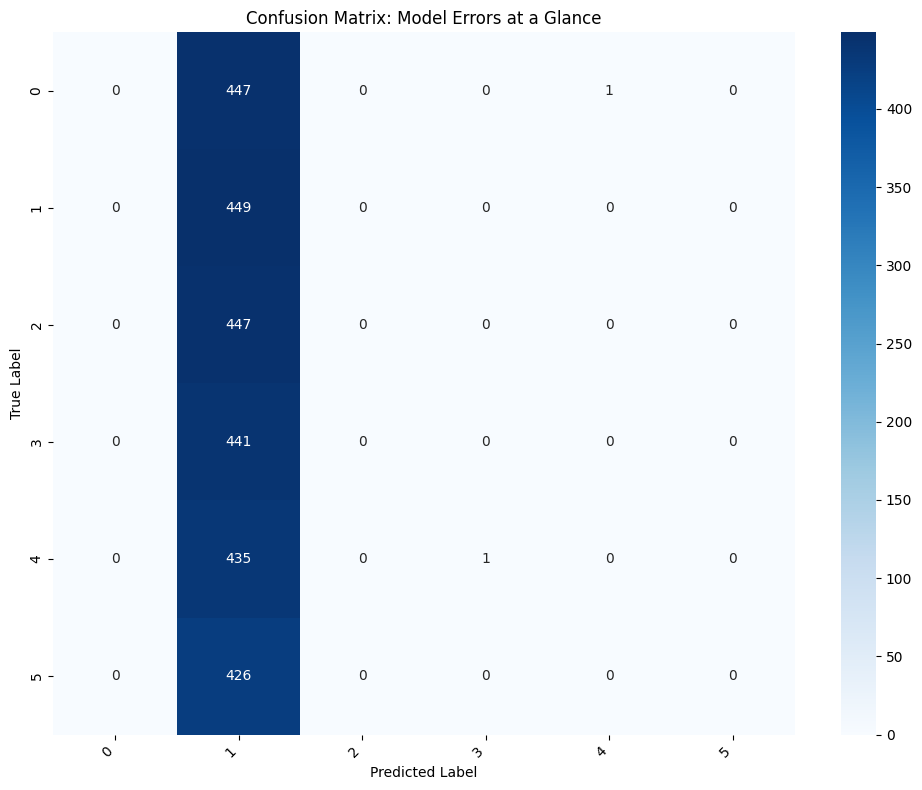

In [21]:
# Testing the MLP
plot_confusion_matrix(model=mlp_model, test_loader=test_loader, class_names=class_names, device=device)

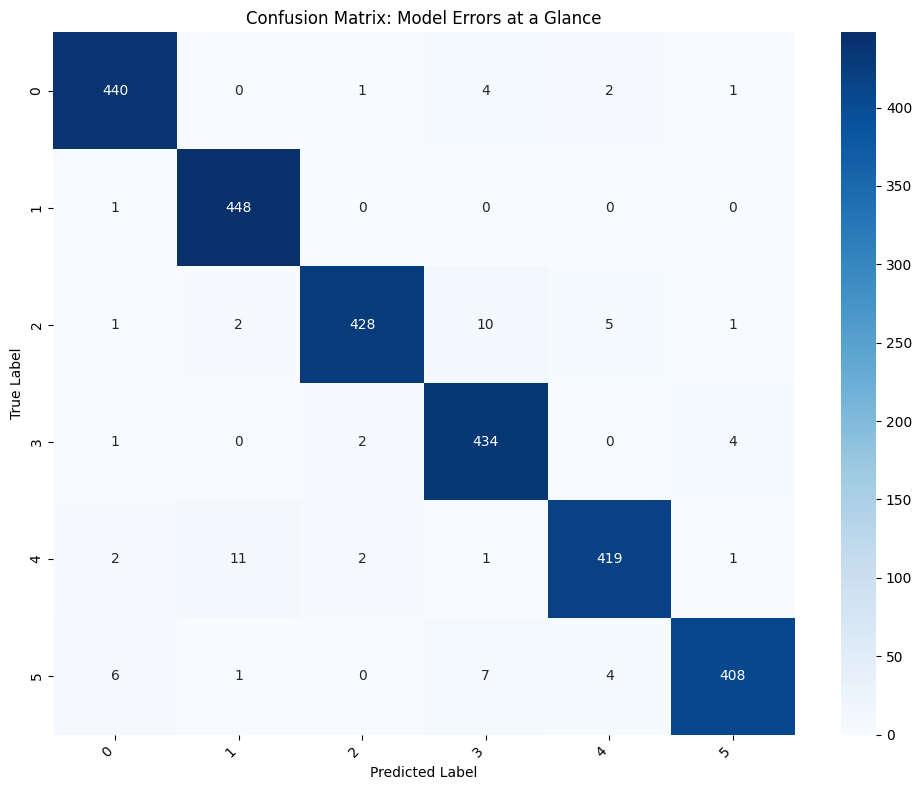

In [22]:
# Testing the CNN
plot_confusion_matrix(model=cnn_model, test_loader=test_loader, class_names=class_names, device=device)

## Droput

**Dropout** is a regularization technique used in neural networks to **reduce overfitting**. It involves **randomly "turning off"** (deactivating) a percentage of neurons during training. This forces the remaining active neurons to learn more robust patterns, as they cannot rely on the presence of the deactivated ones.

Dropout is applied **only during training** and is disabled during evaluation/testing.

In [23]:
class CardCNNWithDropout(nn.Module):
    def __init__(self, num_classes=num_classes, dropout_rate=0.5):
        super(CardCNNWithDropout, self).__init__()

        # First convolutional block
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional block
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        # Third convolutional block
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # Fully connected layers
        # After 3 pooling layers (each reducing by a factor of 2),
        # 224 / 2 / 2 / 2 = 28. So the last feature map size is 64x28x28
        # Flattened size: 64 * 28 * 28 = 50176
        self.fc1 = nn.Linear(64 * 28 * 28, 512)
        self.dropout = nn.Dropout(dropout_rate) # Dropout layer
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Apply first conv -> ReLU -> pool
        x = self.pool(F.relu(self.conv1(x)))
        # Apply second conv -> ReLU -> pool
        x = self.pool(F.relu(self.conv2(x)))
        # Apply third conv -> ReLU -> pool
        x = self.pool(F.relu(self.conv3(x)))

        # Flatten the feature maps for the fully connected layer
        x = x.view(-1, 64 * 28 * 28)

        # Apply fully connected layers with ReLU activation and Dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x) # Apply dropout
        x = self.fc2(x)
        return x

print(f"CNN with Dropout defined with {num_classes} output classes and dropout rate of 0.5.")

CNN with Dropout defined with 6 output classes and dropout rate of 0.5.


In [24]:
# Train the model
model_cnn_dropout = CardCNNWithDropout(num_classes=num_classes, dropout_rate=0.5)
cnn_dropout_optimizer = torch.optim.Adam(model_cnn_dropout.parameters(), lr=0.001)

history_cnn_dropout = train_model(model=model_cnn_dropout, train_loader=train_loader, test_loader=test_loader, criterion=criterion, optimizer=cnn_dropout_optimizer, num_epochs=num_epochs, device=device)

RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

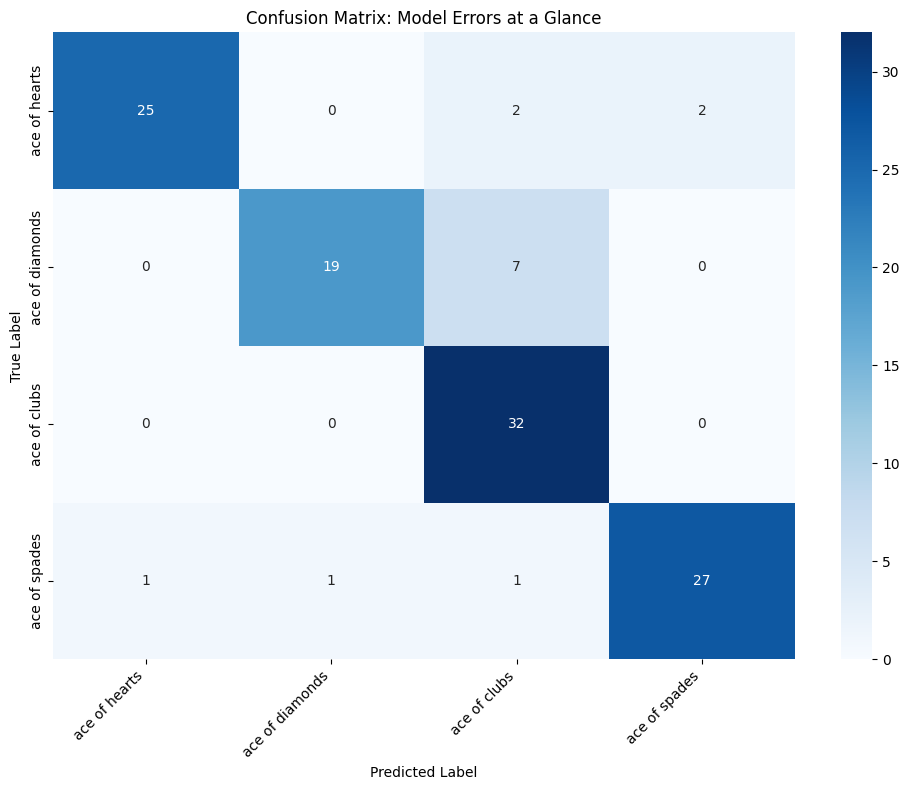

In [ ]:
# Test the model
plot_confusion_matrix(model=model_cnn_dropout, test_loader=test_loader, class_names=class_names, device=device)